## Images: compression and denoising in 2D

An image is just a point cloud: one point per pixel centre, one value per point. Nothing in the
samplet construction knows that the points form a grid, and the last section of this notebook
exploits that: the same code denoises an image sampled at **randomly scattered** locations,
where a classical 2D wavelet transform does not apply at all.

In [1]:
# the KMP setting avoids a clash between the OpenMP runtimes of FMCA and numpy
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import time
import numpy as np
import matplotlib.pyplot as plt
import FMCA

plt.rcParams.update({
    "figure.dpi": 80,
    "font.size": 11,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.constrained_layout.use": True,
})
C_DATA, C_SAMP, C_REF = "#1f4e79", "#c1121f", "#2a9d8f"

## The image as a point cloud

grace_hopper.jpg (matplotlib sample data):  600 x 512 pixels, two 1D trees in 0.002 s


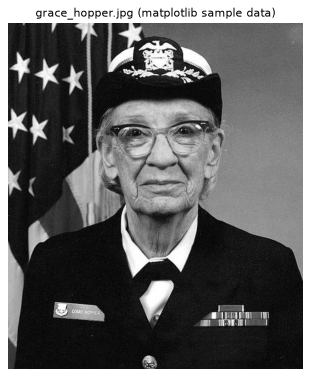

In [2]:
import matplotlib.cbook as cbook

n = 2048
try:
    raw = plt.imread(cbook.get_sample_data("grace_hopper.jpg"))
    img = (raw[..., :3].astype(float) @ np.array([0.2989, 0.5870, 0.1140]))[:n, :n] / 255.0
    title = "grace_hopper.jpg (matplotlib sample data)"
except Exception:                                  # offline fallback: a synthetic image
    gy, gx = np.mgrid[0:n, 0:n] / (n - 1)
    img = (0.5 + 0.4 * np.sin(8 * np.pi * gx) * np.cos(6 * np.pi * gy)
           + 0.4 * ((gx - 0.6) ** 2 + (gy - 0.4) ** 2 < 0.03))
    img = np.clip(img, 0, 1)
    title = "synthetic test image"

ny, nx = img.shape
N = ny * nx

# one 1D samplet tree per direction: x along the rows, y along the columns
X = np.linspace(0, 1, nx).reshape(1, nx)
Y = np.linspace(0, 1, ny).reshape(1, ny)
t0 = time.time()
STx = FMCA.SampletTree(X, 3)
STy = FMCA.SampletTree(Y, 3)
print(f"{title}:  {ny} x {nx} pixels, two 1D trees in {time.time() - t0:.3f} s")

plt.figure(figsize=(4.6, 4.6))
plt.imshow(img, cmap="gray", vmin=0, vmax=1)
plt.title(title, fontsize=10)
plt.axis("off")
plt.show()

samplet transform of 307200 values: 0.0062 s


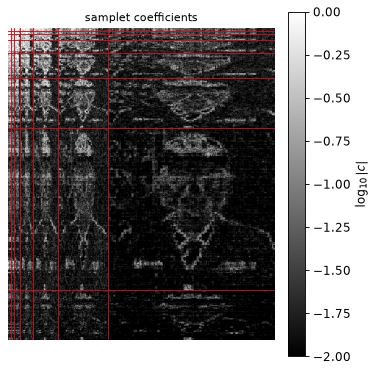

In [3]:
def transform2d(A):
    """samplet transform of every column (along y), then of every row (along x)"""
    B = STy.sampletTransform(STy.toClusterOrder(A))
    return STx.sampletTransform(STx.toClusterOrder(B.T)).T

def inverse2d(C):
    """inverse of transform2d, back in natural pixel order"""
    B = STx.toNaturalOrder(STx.inverseSampletTransform(C.T)).T
    return STy.toNaturalOrder(STy.inverseSampletTransform(B))

t0 = time.time()
c = transform2d(img)
print(f"samplet transform of {N} values: {time.time() - t0:.4f} s")

plt.figure(figsize=(4.6, 4.6))
ly, lx = np.asarray(STy.levels()), np.asarray(STx.levels())
for L in np.unique(ly)[1:]:
    plt.axhline(np.argmax(ly == L) - 0.5, color="#c1121f", lw=0.8)
for L in np.unique(lx)[1:]:
    plt.axvline(np.argmax(lx == L) - 0.5, color="#c1121f", lw=0.8)
plt.imshow(np.log10(np.abs(c) + 1e-12), cmap="gray", vmin=-2, vmax=0)
plt.colorbar(label=r"$\log_{10}|c|$")
plt.title("samplet coefficients", fontsize=10)
plt.axis("off")
plt.show()


## Compression: keep the largest coefficients

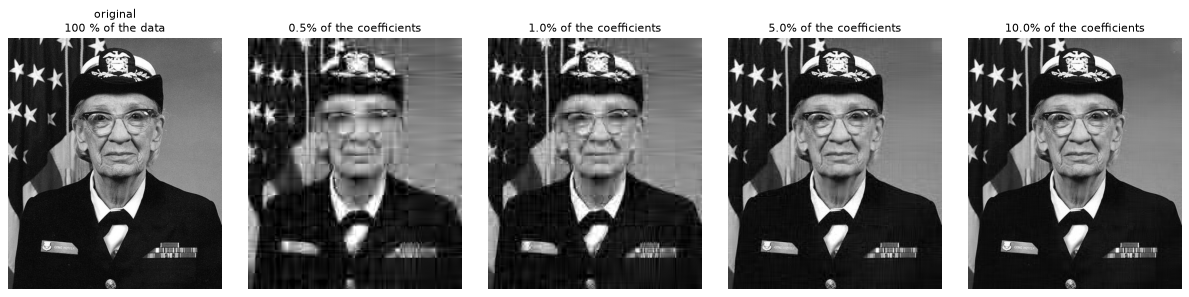

In [4]:
def best_k_term(coeffs, k):
    out = np.zeros_like(coeffs)
    sel = np.argpartition(np.abs(coeffs.ravel()), -k)[-k:]
    out.ravel()[sel] = coeffs.ravel()[sel]
    return out


keeps = [0.005, 0.01, 0.05, 0.10]
fig, axes = plt.subplots(1, len(keeps) + 1, figsize=(15, 3.6))
axes[0].imshow(img, cmap="gray", vmin=0, vmax=1)
axes[0].set_title("original\n100 % of the data", fontsize=10)
for ax, keep in zip(axes[1:], keeps):
    k = int(keep * N)
    rec = inverse2d(best_k_term(c, k))
    ax.imshow(rec, cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"{keep:.1%} of the coefficients", fontsize=10)
for ax in axes:
    ax.axis("off")
plt.show()

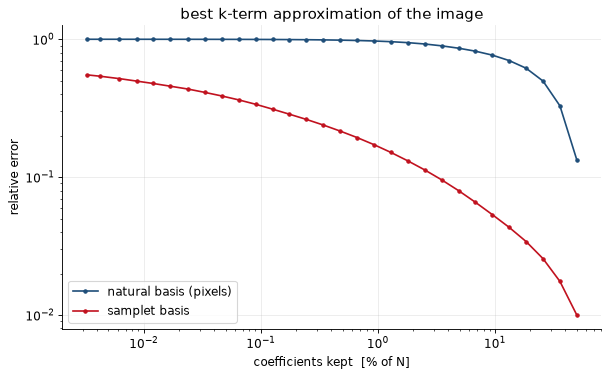

In [5]:
ks = np.unique(np.logspace(1, np.log10(N / 2), 30).astype(int))
err_s = [np.linalg.norm(inverse2d(best_k_term(c, k)) - img)
         / np.linalg.norm(img) for k in ks]
err_n = [np.linalg.norm(best_k_term(img, k) - img) / np.linalg.norm(img) for k in ks]

plt.figure(figsize=(7.5, 4.6))
plt.loglog(100 * ks / N, err_n, "o-", ms=3, color=C_DATA, label="natural basis (pixels)")
plt.loglog(100 * ks / N, err_s, "o-", ms=3, color=C_SAMP, label="samplet basis")
plt.xlabel("coefficients kept  [% of N]")
plt.ylabel("relative error")
plt.title("best k-term approximation of the image")
plt.legend()
plt.show()

## Denoising

Same recipe as in 1D. For a natural image the universal threshold is a little too aggressive
(images are not smooth), so a fraction of it is used; a short sweep finds the best value.

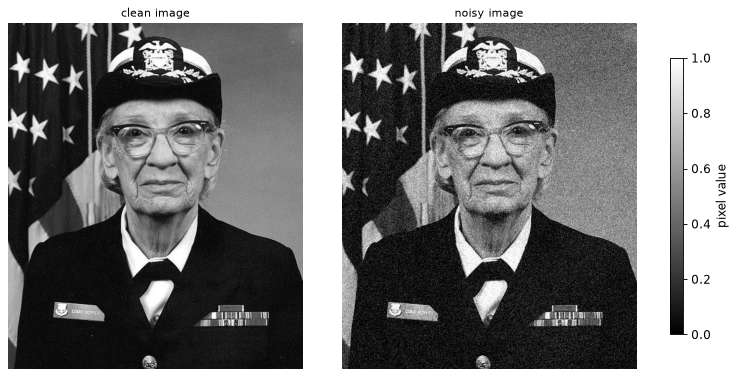

In [6]:
sigma = 0.1
noisy = img + sigma * np.random.randn(*img.shape)
# plot image and noisy image 
fig, axes = plt.subplots(1, 2, figsize=(9.5, 4.6))
for ax, (pic, ttl) in zip(axes, [(img, "clean image"), (noisy, "noisy image")]):
    im = ax.imshow(pic, cmap="gray", vmin=0, vmax=1)
    ax.set_title(ttl, fontsize=10)
    ax.axis("off")
fig.colorbar(im, ax=axes, label="pixel value", shrink=0.8)

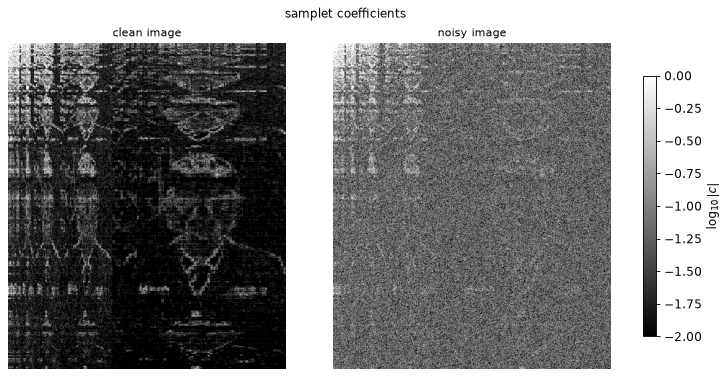

In [7]:
c_noisy = transform2d(noisy)

fig, axes = plt.subplots(1, 2, figsize=(9.5, 4.6))
for ax, (coef, ttl) in zip(axes, [(c, "clean image"), (c_noisy, "noisy image")]):
    im = ax.imshow(np.log10(np.abs(coef) + 1e-12), cmap="gray", vmin=-2, vmax=0)
    ax.set_title(ttl, fontsize=10)
    ax.axis("off")
fig.colorbar(im, ax=axes, label=r"$\log_{10}|c|$", shrink=0.8)
fig.suptitle("samplet coefficients", fontsize=11)
plt.show()

estimated sigma 0.1014 (true 0.1),  46303 of 307200 coefficients kept


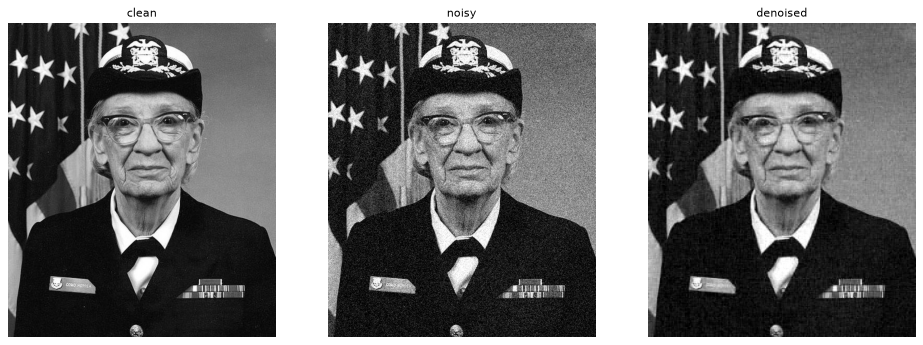

In [8]:
sy, sx = STy.nscalfs(), STx.nscalfs()

# band of every row / column: -1 for the scaling functions, otherwise the level
by = np.asarray(STy.levels()).astype(int); by[:sy] = -1
bx = np.asarray(STx.levels()).astype(int); bx[:sx] = -1

# noise level estimated from the finest band (median absolute deviation),
# as in wavelet denoising: there the coefficients are almost only noise
finest = c_noisy[np.ix_(by == by.max(), bx == bx.max())]
sigma_est = np.median(np.abs(finest)) / 0.6745

# BayesShrink: one soft threshold per band, sigma^2 / (signal std in the band)
cc = c_noisy.copy()
for a in np.unique(by):
    for b in np.unique(bx):
        if a == -1 and b == -1:
            continue                                        # scaling coefficients untouched
        rows, cols = np.ix_(by == a, bx == b)
        d = c_noisy[rows, cols]
        signal_std = np.sqrt(max(np.mean(d ** 2) - sigma_est ** 2, 0.0))
        t = np.inf if signal_std == 0 else sigma_est ** 2 / signal_std
        cc[rows, cols] = np.sign(d) * np.maximum(np.abs(d) - t, 0.0)
den = inverse2d(cc)

print(f"estimated sigma {sigma_est:.4f} (true {sigma}),  "
      f"{int((cc != 0).sum())} of {N} coefficients kept")

fig, axes = plt.subplots(1, 3, figsize=(12, 4.2))
for ax, (pic, ttl) in zip(axes, [(img, "clean"),
                                 (noisy, f"noisy"),
                                 (den, f"denoised")]):
    ax.imshow(np.clip(pic, 0, 1), cmap="gray", vmin=0, vmax=1)
    ax.set_title(ttl, fontsize=10)
    ax.axis("off")
plt.show()

noisy 20.00 dB,  samplets 26.59 dB,  wavelets 26.52 dB


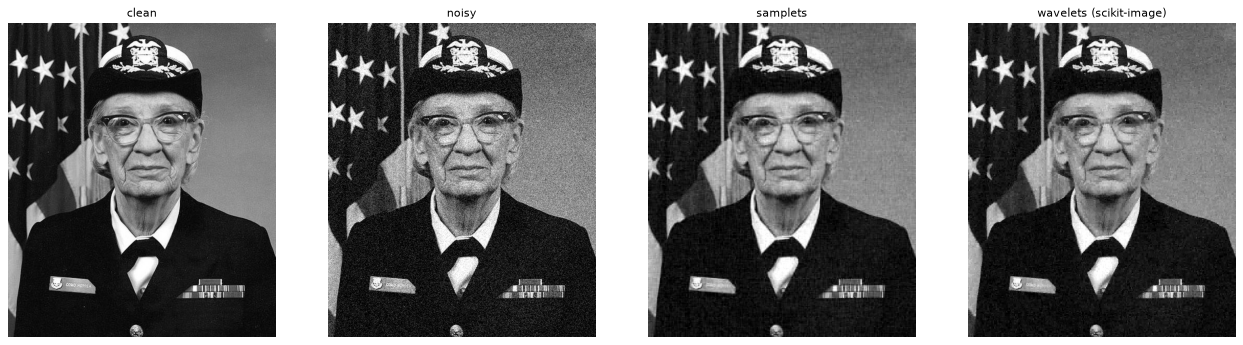

In [9]:
from skimage.restoration import denoise_wavelet

# the standard wavelet reference: BayesShrink, soft
# threshold, sigma estimated from the data
den_wavelet = denoise_wavelet(noisy, method="BayesShrink", mode="soft")

psnr = lambda a: 10 * np.log10(1.0 / np.mean((a - img) ** 2))
print(f"noisy {psnr(noisy):.2f} dB,  samplets {psnr(den):.2f} dB,  "
      f"wavelets {psnr(den_wavelet):.2f} dB")

fig, axes = plt.subplots(1, 4, figsize=(16, 4.2))
for ax, (pic, ttl) in zip(axes, [(img, "clean"),
                                 (noisy, "noisy"),
                                 (den, "samplets"),
                                 (den_wavelet, "wavelets (scikit-image)")]):
    ax.imshow(np.clip(pic, 0, 1), cmap="gray", vmin=0, vmax=1)
    ax.set_title(ttl, fontsize=10)
    ax.axis("off")
plt.show()